#Data Loading

In [ ]:
import pickle
import numpy as np

# Load the pickle file
with open('circle_eight_preprocessed.pickle', 'rb') as f:
  data = pickle.load(f)

# Check what we loaded
print(type(data))
print(data.keys())

X_feat = np.concatenate([data[('circle', 'X_feat')], data[('eight', 'X_feat')]])
X_crop = np.concatenate([data[('circle', 'X_crop')], data[('eight', 'X_crop')]])
X_resampling = np.concatenate([data[('circle', 'X_resampling')], data[('eight', 'X_resampling')]])
X_labeled_feat = X_feat
y_labeled_feat = np.concatenate([
    data[('circle', 'y')],
    data[('eight', 'y')]
])
X_labeled_crop = X_crop
y_labeled_crop = np.concatenate([
    data[('circle', 'y')],
    data[('eight', 'y')]
])
X_labeled_resampling = X_resampling
y_labeled_resampling = np.concatenate([
    data[('circle', 'y')],
    data[('eight', 'y')]
])

<class 'dict'>
dict_keys([('circle', 'X_feat'), ('circle', 'X_crop'), ('circle', 'X_resampling'), ('circle', 'y'), ('eight', 'X_feat'), ('eight', 'X_crop'), ('eight', 'X_resampling'), ('eight', 'y')])


#Generic Classes

In [ ]:
import random

class SimCLRTransform: #transformation for feature vectors
  def __init__(self, noise_std=0.1, p_drop=0.2, p_noise=1, p_dropout=1, p_scaling=0.7, p_masking=0.3, mask_size=3):
    self.noise_std = noise_std
    self.p_drop = p_drop
    self.p_noise = p_noise
    self.p_dropout = p_dropout
    self.p_scaling = p_scaling
    self.p_masking = p_masking
    self.mask_size = mask_size

  def add_gaussian(self, x): #function of adding gaussian noise
    if random.random() < self.p_noise:
      noise = np.random.normal(0, self.noise_std, x.shape)
      x = x + noise
    return x

  def dropout(self, x): #function of randomly features dropout
    if random.random() < self.p_dropout:
      mask = np.random.binomial(1, 1 - self.p_drop, size=x.shape) #keeps the entry which the mask on it is 1
      x = x * mask
    return x

  def scaling(self, x): #change the scaling of whole vector
    if random.random() < self.p_scaling:
      scale = np.random.uniform(0.9, 1.1) #get a scaling factor between 0.9 and 1.1
      x = x * scale
    return x

  def masking(self, x): #mask out a little portion of features(set to 0)
    if random.random() < self.p_masking:
      x = np.array(x, copy=True)
      start_point = random.randint(0, max(0, len(x) - self.mask_size))
      x[start_point : start_point + self.mask_size] = 0
    return x

  def __call__(self, x): #apply tranformation
      x = np.array(x, copy=True) #avoid changing the original x
      x = self.add_gaussian(x)
      x = self.dropout(x)
      x = self.scaling(x)
      x = self.masking(x)
      return x.astype(np.float32)

In [ ]:
import torch
from torch.utils.data import Dataset

class SimCLRDataset(Dataset):
  def __init__(self, x_vector, transform):
    self.x_vector = x_vector.astype(np.float32)
    self.transofrom = transform

  def __len__(self):
    return len(self.x_vector)

  def __getitem__(self, idx):
    x = self.x_vector[idx]
    x = np.array(x, dtype=np.float32)
    x_i = self.transofrom(x)
    x_j = self.transofrom(x)
    return torch.tensor(x_i, dtype=torch.float32), torch.tensor(x_j, dtype=torch.float32)

In [ ]:
import torch.nn as nn

class NTXentLoss(nn.Module):
  def __init__(self, temperature=0.5):
    super(NTXentLoss, self).__init__()
    self.temperature = temperature #define the sharpness of contrast(lower = harder)

  def forward(self, z_i, z_j):

    #normalize(require for cosine similarity)
    z_i = f.normalize(z_i, dim=1)
    z_j = f.normalize(z_j, dim=1)

    z = torch.cat([z_i, z_j], dim=0) #combine two views
    similarity = torch.matmul(z, z.transpose(0, 1)) / self.temperature #each row in similarity is compared to all others(including itself which we don't want it to happen)
    batch_size = z_i.size(0)
    mask = torch.eye(2 * batch_size, dtype=torch.bool).to(z.device) #create an identity matrix, which each row has a 1 on the diagonal
    similarity = similarity.masked_fill(mask, float('-inf')) #set all diagonal elements in similarity to -inf to prevent it to compare with itself

    positives = torch.cat([
        torch.arange(batch_size, 2 * batch_size),
        torch.arange(0, batch_size)
    ]).to(z.device) #tells the loss function the correct match

    loss = f.cross_entropy(similarity, positives)
    return loss

# X_feat

In [ ]:
class SimCLRModel(nn.Module):
  def __init__(self, projection_dim=64):
    super(SimCLRModel, self).__init__()

    self.encoder = nn.Sequential(
        nn.Linear(30, 128),
        nn.ReLU(),
        nn.Linear(128, 128),
        nn.ReLU()
    )

    self.projector = nn.Sequential(
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, projection_dim) #project encoder output into lower dimensional space, making it easier to learn contrastive similarities
    )

  def forward(self, x):
    h = self.encoder(x)
    z = self.projector(h)
    return z

In [ ]:
from torch.utils.data import DataLoader

transform_feat = SimCLRTransform()
dataset = SimCLRDataset(X_feat, transform_feat)
loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

In [ ]:
import torch.optim as optim
import torch.nn.functional as f

epochs = 2000
learning_rate = 1e-3
weight_decay = 1e-6
temperature = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_feat = SimCLRModel().to(device)
optimizer_feat = optim.Adam(model_feat.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss_function = NTXentLoss(temperature=temperature)

for epoch in range(epochs):
  model_feat.train()
  total_loss_feat = 0

  for x_i, x_j in loader:
    x_i = x_i.to(device)
    x_j = x_j.to(device)
    z_i = model_feat(x_i)
    z_j = model_feat(x_j)

    loss = loss_function(z_i, z_j)
    optimizer_feat.zero_grad()
    loss.backward()
    optimizer_feat.step()

    total_loss_feat += loss.item()

  average_loss = total_loss_feat / len(loader)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {average_loss:.4f}")


Epoch 1/2000, Loss: 4.8468
Epoch 2/2000, Loss: 4.8437
Epoch 3/2000, Loss: 4.8433
Epoch 4/2000, Loss: 4.8468
Epoch 5/2000, Loss: 4.8443
Epoch 6/2000, Loss: 4.8438
Epoch 7/2000, Loss: 4.8436
Epoch 8/2000, Loss: 4.8443
Epoch 9/2000, Loss: 4.8446
Epoch 10/2000, Loss: 4.8439
Epoch 11/2000, Loss: 4.8450
Epoch 12/2000, Loss: 4.8435
Epoch 13/2000, Loss: 4.8445
Epoch 14/2000, Loss: 4.8446
Epoch 15/2000, Loss: 4.8438
Epoch 16/2000, Loss: 4.8441
Epoch 17/2000, Loss: 4.8443
Epoch 18/2000, Loss: 4.8446
Epoch 19/2000, Loss: 4.8440
Epoch 20/2000, Loss: 4.8446
Epoch 21/2000, Loss: 4.8443
Epoch 22/2000, Loss: 4.8441
Epoch 23/2000, Loss: 4.8442
Epoch 24/2000, Loss: 4.8442
Epoch 25/2000, Loss: 4.8442
Epoch 26/2000, Loss: 4.8440
Epoch 27/2000, Loss: 4.8444
Epoch 28/2000, Loss: 4.8443
Epoch 29/2000, Loss: 4.8440
Epoch 30/2000, Loss: 4.8442
Epoch 31/2000, Loss: 4.8440
Epoch 32/2000, Loss: 4.8443
Epoch 33/2000, Loss: 4.8443
Epoch 34/2000, Loss: 4.8444
Epoch 35/2000, Loss: 4.8441
Epoch 36/2000, Loss: 4.8442
E

Accuracy: 90.36%
Precision: 100.00%
Recall: 80.00%
F1: 88.89%


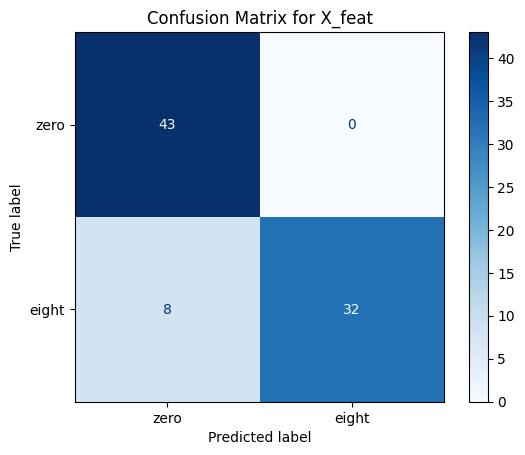

In [ ]:
import torch, numpy as np
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_train_feat, x_test_feat, y_train_feat, y_test_feat = train_test_split(X_labeled_feat, y_labeled_feat, test_size=0.2, random_state=42, stratify=y_labeled_feat) #ensures the class ratio is balanced

# converts into PyTorch tensors
y_train_f = torch.tensor(y_train_feat, dtype=torch.long, device=device)
y_test_f = torch.tensor(y_test_feat,  dtype=torch.long, device=device)

#freezes encoder
for p in model_feat.encoder.parameters():
    p.requires_grad = False

#linear probing(warm up)
linear_head_f = torch.nn.Linear(128, 2).to(device) #fully connected layer(input = 128-D feature vector from encoder)
optimizer_head_f = torch.optim.Adam(linear_head_f.parameters(), lr=1e-3, weight_decay=1e-6)
loss_fn = torch.nn.CrossEntropyLoss()

n1 = 30
for epoch in range(n1):
    optimizer_head_f.zero_grad()
    raw_feat = torch.tensor(x_train_feat, dtype=torch.float32, device=device)
    h_feat = model_feat.encoder(raw_feat)
    out_feat = linear_head_f(h_feat)
    loss= loss_fn(out_feat, y_train_f)
    loss.backward()
    optimizer_head_f.step()

#Unfreezes encoder and fine-tune encoder + head
for p in model_feat.encoder.parameters():
    p.requires_grad = True

optimizer_ft_f = torch.optim.Adam([
        {'params': model_feat.encoder.parameters(), 'lr': 1e-4},
        {'params': linear_head_f.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-6)

n2 = 40
for epoch in range(n2):
    optimizer_ft_f.zero_grad()
    raw_feat = torch.tensor(x_train_feat, dtype=torch.float32, device=device)
    h_feat = model_feat.encoder(raw_feat)
    out_feat = linear_head_f(h_feat)
    loss= loss_fn(out_feat, y_train_f)
    loss.backward()
    optimizer_ft_f.step()

#result
model_feat.eval()
linear_head_f.eval()
with torch.no_grad():
    raw_test_f = torch.tensor(x_test_feat, dtype=torch.float32, device=device)
    h_test_f = model_feat.encoder(raw_test_f)
    predicted_feat = linear_head_f(h_test_f).argmax(1).cpu()
acc = (predicted_feat == y_test_f.cpu()).float().mean().item() #converts boolean tensor to 0.0 / 1.0 as the label, computes the mean(accuracy), and converts it to plain Python float
print(f"Accuracy: {acc * 100:.2f}%")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

precision_feat = precision_score(y_test_f.cpu(), predicted_feat)
recall_feat = recall_score(y_test_f.cpu(), predicted_feat)
f1_feat = f1_score(y_test_f.cpu(), predicted_feat)
print(f"Precision: {precision_feat * 100:.2f}%")
print(f"Recall: {recall_feat * 100:.2f}%")
print(f"F1: {f1_feat * 100:.2f}%")

confusion_matrix_feat = confusion_matrix(y_test_f.cpu(), predicted_feat)
disp_feat = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_feat, display_labels=["zero", "eight"])
disp_feat.plot(cmap="Blues")
plt.title("Confusion Matrix for X_feat")
plt.show()

#X_crop

In [ ]:
class SimCLRModel_crop(nn.Module):
  def __init__(self, projection_dim=64):
    super(SimCLRModel_crop, self).__init__()

    self.encoder = nn.Sequential(
        nn.Linear(1902, 1024),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.ReLU(),
        nn.Linear(512, 128),
        nn.ReLU()
    )

    self.projector = nn.Sequential(
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, projection_dim) #project encoder output into lower dimensional space, making it easier to learn contrastive similarities
    )

  def forward(self, x):
    h = self.encoder(x)
    z = self.projector(h)
    return z

In [ ]:
transform_crop = SimCLRTransform(p_masking=0)
dataset_crop = SimCLRDataset(X_crop, transform_crop)
loader_crop = DataLoader(dataset_crop, batch_size=64, shuffle=True, drop_last=True)

In [ ]:
import torch.optim as optim
import torch.nn.functional as f

epochs = 2000
learning_rate = 1e-3
weight_decay = 1e-6
temperature = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_crop = SimCLRModel_crop().to(device)
optimizer_crop = optim.Adam(model_crop.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss_function = NTXentLoss(temperature=temperature)

for epoch in range(epochs):
  model_crop.train()
  total_loss_crop = 0

  for x_i, x_j in loader_crop:
    x_i = x_i.to(device)
    x_j = x_j.to(device)
    z_i = model_crop(x_i)
    z_j = model_crop(x_j)

    loss = loss_function(z_i, z_j)
    optimizer_crop.zero_grad()
    loss.backward()
    optimizer_crop.step()

    total_loss_crop += loss.item()

  average_loss_crop = total_loss_crop / len(loader_crop)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {average_loss_crop:.4f}")

Epoch 1/2000, Loss: 4.8065
Epoch 2/2000, Loss: 4.5206
Epoch 3/2000, Loss: 4.0056
Epoch 4/2000, Loss: 3.8210
Epoch 5/2000, Loss: 3.7628
Epoch 6/2000, Loss: 3.6916
Epoch 7/2000, Loss: 3.6645
Epoch 8/2000, Loss: 3.6385
Epoch 9/2000, Loss: 3.6267
Epoch 10/2000, Loss: 3.5993
Epoch 11/2000, Loss: 3.5480
Epoch 12/2000, Loss: 3.5373
Epoch 13/2000, Loss: 3.5225
Epoch 14/2000, Loss: 3.4856
Epoch 15/2000, Loss: 3.5144
Epoch 16/2000, Loss: 3.4740
Epoch 17/2000, Loss: 3.4432
Epoch 18/2000, Loss: 3.4116
Epoch 19/2000, Loss: 3.3522
Epoch 20/2000, Loss: 3.3660
Epoch 21/2000, Loss: 3.3404
Epoch 22/2000, Loss: 3.3094
Epoch 23/2000, Loss: 3.2853
Epoch 24/2000, Loss: 3.2962
Epoch 25/2000, Loss: 3.2433
Epoch 26/2000, Loss: 3.2420
Epoch 27/2000, Loss: 3.2341
Epoch 28/2000, Loss: 3.2410
Epoch 29/2000, Loss: 3.2469
Epoch 30/2000, Loss: 3.2584
Epoch 31/2000, Loss: 3.2206
Epoch 32/2000, Loss: 3.2263
Epoch 33/2000, Loss: 3.2302
Epoch 34/2000, Loss: 3.2304
Epoch 35/2000, Loss: 3.2048
Epoch 36/2000, Loss: 3.2256
E

Accuracy: 87.95%
Precision: 91.67%
Recall: 82.50%
F1: 86.84%


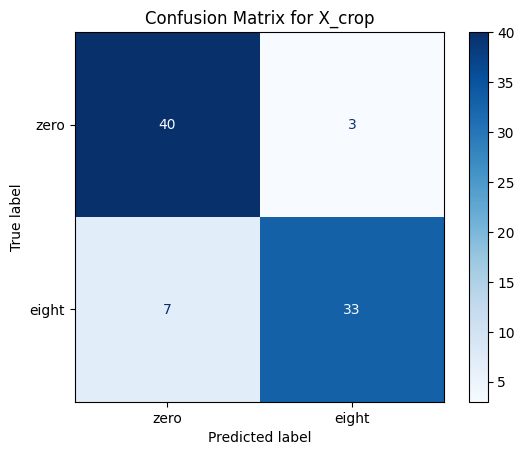

In [ ]:
import torch, numpy as np
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_train_crop, x_test_crop, y_train_crop, y_test_crop = train_test_split(X_labeled_crop, y_labeled_crop, test_size=0.2, random_state=42, stratify=y_labeled_crop) #ensures the class ratio is balanced

# converts into PyTorch tensors
y_train_c = torch.tensor(y_train_crop, dtype=torch.long, device=device)
y_test_c = torch.tensor(y_test_crop,  dtype=torch.long, device=device)

#freezes encoder
for p in model_crop.encoder.parameters():
    p.requires_grad = False

#linear probing(warm up)
linear_head_c = torch.nn.Linear(128, 2).to(device) #fully connected layer(input = 128-D feature vector from encoder)
optimizer_head_c = torch.optim.Adam(linear_head_c.parameters(), lr=1e-3, weight_decay=1e-6)
loss_fn = torch.nn.CrossEntropyLoss()

n1 = 30
for epoch in range(n1):
    optimizer_head_c.zero_grad()
    raw_crop = torch.tensor(x_train_crop, dtype=torch.float32, device=device)
    h_crop = model_crop.encoder(raw_crop)
    out_crop = linear_head_c(h_crop)
    loss= loss_fn(out_crop, y_train_c)
    loss.backward()
    optimizer_head_c.step()

#Unfreezes encoder and fine-tune encoder + head
for p in model_crop.encoder.parameters():
    p.requires_grad = True

optimizer_ft = torch.optim.Adam([
        {'params': model_crop.encoder.parameters(), 'lr': 1e-4},
        {'params': linear_head_c.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-6)

n2 = 40
for epoch in range(n2):
    optimizer_ft.zero_grad()
    raw_crop = torch.tensor(x_train_crop, dtype=torch.float32, device=device)
    h_crop = model_crop.encoder(raw_crop)
    out_crop = linear_head_c(h_crop)
    loss= loss_fn(out_crop, y_train_c)
    loss.backward()
    optimizer_ft.step()

#result
model_crop.eval()
linear_head_c.eval()
with torch.no_grad():
    raw_test_c = torch.tensor(x_test_crop, dtype=torch.float32, device=device)
    h_test_c = model_crop.encoder(raw_test_c)
    predicted_crop = linear_head_c(h_test_c).argmax(1).cpu()
acc = (predicted_crop == y_test_c.cpu()).float().mean().item() #converts boolean tensor to 0.0 / 1.0 as the label, computes the mean(accuracy), and converts it to plain Python float
print(f"Accuracy: {acc * 100:.2f}%")

precision = precision_score(y_test_c.cpu(), predicted_crop)
recall = recall_score(y_test_c.cpu(), predicted_crop)
f1 = f1_score(y_test_c.cpu(), predicted_crop)
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1: {f1 * 100:.2f}%")

confusion_matrix_crop = confusion_matrix(y_test_c.cpu(), predicted_crop)
disp_crop = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_crop, display_labels=["zero", "eight"])
disp_crop.plot(cmap="Blues")
plt.title("Confusion Matrix for X_crop")
plt.show()

#X_resampling

In [ ]:
class SimCLRModel_resampling(nn.Module):
  def __init__(self, projection_dim=64):
    super(SimCLRModel_resampling, self).__init__()

    self.encoder = nn.Sequential(
        nn.Linear(1902, 1024),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.ReLU(),
        nn.Linear(512, 128),
        nn.ReLU()
    )

    self.projector = nn.Sequential(
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, projection_dim) #project encoder output into lower dimensional space, making it easier to learn contrastive similarities
    )

  def forward(self, x):
    h = self.encoder(x)
    z = self.projector(h)
    return z

In [ ]:
transform_resampling = SimCLRTransform(p_masking=0)
dataset_resampling = SimCLRDataset(X_resampling, transform_resampling)
loader_resampling = DataLoader(dataset_resampling, batch_size=64, shuffle=True, drop_last=True)

In [ ]:
import torch.optim as optim
import torch.nn.functional as f

epochs = 2000
learning_rate = 1e-3
weight_decay = 1e-6
temperature = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_resampling = SimCLRModel_resampling().to(device)
optimizer_resampling = optim.Adam(model_resampling.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss_function = NTXentLoss(temperature=temperature)

for epoch in range(epochs):
  model_resampling.train()
  total_loss_resampling = 0

  for x_i, x_j in loader_resampling:2
    x_i = x_i.to(device)
    x_j = x_j.to(device)
    z_i = model_resampling(x_i)
    z_j = model_resampling(x_j)

    loss = loss_function(z_i, z_j)
    optimizer_resampling.zero_grad()
    loss.backward()
    optimizer_resampling.step()

    total_loss_resampling += loss.item()

  average_loss_resampling = total_loss_resampling / len(loader_resampling)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {average_loss_resampling:.4f}")

Epoch 1/2000, Loss: 4.8034
Epoch 2/2000, Loss: 4.3131
Epoch 3/2000, Loss: 3.8583
Epoch 4/2000, Loss: 3.6940
Epoch 5/2000, Loss: 3.6143
Epoch 6/2000, Loss: 3.5116
Epoch 7/2000, Loss: 3.4968
Epoch 8/2000, Loss: 3.4747
Epoch 9/2000, Loss: 3.4515
Epoch 10/2000, Loss: 3.4057
Epoch 11/2000, Loss: 3.3744
Epoch 12/2000, Loss: 3.3744
Epoch 13/2000, Loss: 3.3374
Epoch 14/2000, Loss: 3.3745
Epoch 15/2000, Loss: 3.3400
Epoch 16/2000, Loss: 3.3231
Epoch 17/2000, Loss: 3.3189
Epoch 18/2000, Loss: 3.2816
Epoch 19/2000, Loss: 3.2588
Epoch 20/2000, Loss: 3.2525
Epoch 21/2000, Loss: 3.2507
Epoch 22/2000, Loss: 3.2779
Epoch 23/2000, Loss: 3.2724
Epoch 24/2000, Loss: 3.2602
Epoch 25/2000, Loss: 3.2515
Epoch 26/2000, Loss: 3.2611
Epoch 27/2000, Loss: 3.2594
Epoch 28/2000, Loss: 3.2347
Epoch 29/2000, Loss: 3.2149
Epoch 30/2000, Loss: 3.2025
Epoch 31/2000, Loss: 3.1892
Epoch 32/2000, Loss: 3.2193
Epoch 33/2000, Loss: 3.2092
Epoch 34/2000, Loss: 3.2002
Epoch 35/2000, Loss: 3.1970
Epoch 36/2000, Loss: 3.1969
E

Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1: 100.00%


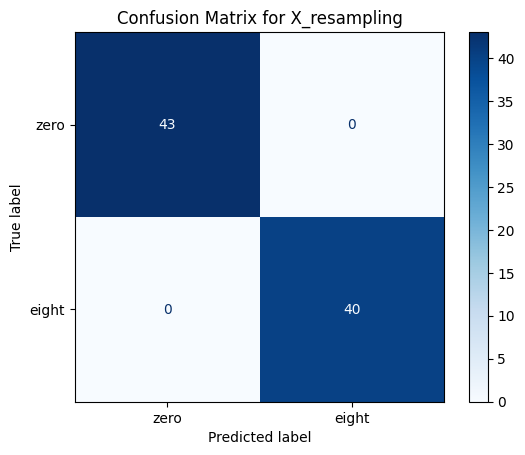

In [ ]:
import torch, numpy as np
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_train_resampling, x_test_resampling, y_train_resampling, y_test_resampling = train_test_split(X_labeled_resampling, y_labeled_resampling, test_size=0.2, random_state=42, stratify=y_labeled_resampling) #ensures the class ratio is balanced

# converts into PyTorch tensors
y_train_r = torch.tensor(y_train_resampling, dtype=torch.long, device=device)
y_test_r = torch.tensor(y_test_resampling,  dtype=torch.long, device=device)

#freezes encoder
for p in model_resampling.encoder.parameters():
    p.requires_grad = False

#linear probing(warm up)
linear_head_r = torch.nn.Linear(128, 2).to(device) #fully connected layer(input = 128-D feature vector from encoder)
optimizer_head_r = torch.optim.Adam(linear_head_r.parameters(), lr=1e-3, weight_decay=1e-6)
loss_fn = torch.nn.CrossEntropyLoss()

n1 = 30
for epoch in range(n1):
    optimizer_head_r.zero_grad()
    raw_resampling = torch.tensor(x_train_resampling, dtype=torch.float32, device=device)
    h_resampling = model_resampling.encoder(raw_resampling)
    out_resampling = linear_head_r(h_resampling)
    loss= loss_fn(out_resampling, y_train_r)
    loss.backward()
    optimizer_head_r.step()

#Unfreezes encoder and fine-tune encoder + head
for p in model_resampling.encoder.parameters():
    p.requires_grad = True

optimizer_ft_r = torch.optim.Adam([
        {'params': model_resampling.encoder.parameters(), 'lr': 1e-4},
        {'params': linear_head_r.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-6)

n2 = 40
for epoch in range(n2):
    optimizer_ft.zero_grad()
    raw_resampling = torch.tensor(x_train_resampling, dtype=torch.float32, device=device)
    h_resampling = model_resampling.encoder(raw_resampling)
    out_resampling = linear_head_r(h_resampling)
    loss= loss_fn(out_resampling, y_train_r)
    loss.backward()
    optimizer_ft.step()

#result
model_resampling.eval()
linear_head_r.eval()
with torch.no_grad():
    raw_test_r = torch.tensor(x_test_resampling, dtype=torch.float32, device=device)
    h_test_r = model_resampling.encoder(raw_test_r)
    predicted_resampling = linear_head_r(h_test_r).argmax(1).cpu()
acc = (predicted_resampling == y_test_r.cpu()).float().mean().item() #converts boolean tensor to 0.0 / 1.0 as the label, computes the mean(accuracy), and converts it to plain python float
print(f"Accuracy: {acc * 100:.2f}%")

precision = precision_score(y_test_r.cpu(), predicted_resampling)
recall = recall_score(y_test_r.cpu(), predicted_resampling)
f1 = f1_score(y_test_r.cpu(), predicted_resampling)
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1: {f1 * 100:.2f}%")

confusion_matrix_resampling = confusion_matrix(y_test_r.cpu(), predicted_resampling)
disp_feat = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_resampling, display_labels=["zero", "eight"])
disp_feat.plot(cmap="Blues")
plt.title("Confusion Matrix for X_resampling")
plt.show()